Загрузка данных

In [ ]:
import psycopg2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from scipy import stats
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')

# Параметры подключения (замените пароль на свой)
DB_CONFIG = {
    'host': 'localhost',        # или 'host.docker.internal', если PostgreSQL в Docker
    'port': 5432,
    'dbname': 'market_data',
    'user': 'postgres',
    'password': '--------'  # укажите свой пароль
}

# Подключение к БД и загрузка данных за 2023 год
query = """
SELECT 
    date,
    client_id,
    gender,
    product_id,
    quantity,
    price_per_item,
    discount_per_item,
    total_price,
    purchase_time_as_seconds_from_midnight
FROM transactions
WHERE EXTRACT(YEAR FROM date) = 2023
"""

conn = psycopg2.connect(**DB_CONFIG)
df = pd.read_sql(query, conn)
conn.close()

# Преобразование типов
df['date'] = pd.to_datetime(df['date'])
df['purchase_datetime'] = df['date']  # у нас нет отдельной колонки, но можно создать для совместимости

# Добавляем вспомогательные колонки
df['month'] = df['date'].dt.month
df['day_of_week'] = df['date'].dt.dayofweek
df['hour'] = df['purchase_time_as_seconds_from_midnight'] // 3600  # часы из секунд

print(f"Загружено {len(df)} транзакций")
print(f"Уникальных клиентов: {df['client_id'].nunique()}")
print(f"Уникальных товаров: {df['product_id'].nunique()}")
print(f"Период: с {df['date'].min()} по {df['date'].max()}")
df.head()

Загружено 2040076 транзакций
Уникальных клиентов: 869966
Уникальных товаров: 50000
Период: с 2023-01-01 00:00:00 по 2023-12-31 00:00:00


,date,client_id,gender,product_id,quantity,price_per_item,discount_per_item,total_price,purchase_time_as_seconds_from_midnight,purchase_datetime,month,day_of_week,hour
0,2023-01-01,789213,F,19852,28,91786.0,27001.0,1813980.0,1698,2023-01-01,1,6,0
1,2023-01-01,851714,M,8396,24,65967.0,45113.0,500496.0,36354,2023-01-01,1,6,10
2,2023-01-01,475254,M,44053,6,26748.0,22573.0,25050.0,8650,2023-01-01,1,6,2
3,2023-01-01,692821,M,7245,65,54835.0,27191.0,1796860.0,59829,2023-01-01,1,6,16
4,2023-01-01,359923,F,12201,6,50860.0,17648.0,199272.0,35170,2023-01-01,1,6,9


Блок 1. Агрегация по товарам (подготовка для ABC-XYZ)

In [12]:
# Агрегация по товарам
product_stats = df.groupby('product_id').agg({
    'total_price': ['sum', 'count'],
    'quantity': 'sum',
    'client_id': 'nunique'
}).reset_index()
product_stats.columns = ['product_id', 'revenue', 'transaction_count', 'total_quantity', 'unique_clients']

# Средняя цена и её вариация
price_stats = df.groupby('product_id')['price_per_item'].agg(['mean', 'std']).reset_index()
product_stats = product_stats.merge(price_stats, on='product_id')
product_stats.rename(columns={'mean': 'avg_price', 'std': 'price_std'}, inplace=True)
product_stats['price_variation'] = product_stats['price_std'] / product_stats['avg_price']

# Оценочная маржинальность (себестоимость = 70% от цены)
product_stats['estimated_margin'] = (product_stats['avg_price'] - product_stats['avg_price'] * 0.7) * product_stats['total_quantity']
product_stats['margin_percent'] = (product_stats['estimated_margin'] / product_stats['revenue']) * 100

print(f"Всего товаров: {len(product_stats)}")
product_stats.head()

Всего товаров: 50000


,product_id,revenue,transaction_count,total_quantity,unique_clients,avg_price,price_std,price_variation,estimated_margin,margin_percent
0,0,39823510.0,33,1314,33,54389.0,0.0,0.0,21440143.8,53.837906
1,1,33656559.0,44,1375,44,47397.0,0.0,0.0,19551262.5,58.090497
2,2,62382314.0,59,2030,59,61127.0,0.0,0.0,37226343.0,59.674514
3,3,39016027.0,32,970,32,80243.0,0.0,0.0,23350713.0,59.849028
4,4,60137169.0,38,1188,38,93106.0,0.0,0.0,33182978.4,55.178817


Блок 2. ABC-классификация

In [13]:
# ABC-классификация по выручке
product_stats['revenue_percent'] = product_stats['revenue'] / product_stats['revenue'].sum() * 100
product_stats = product_stats.sort_values('revenue', ascending=False)
product_stats['cumulative_percent'] = product_stats['revenue_percent'].cumsum()

product_stats['abc_class'] = 'C'
product_stats.loc[product_stats['cumulative_percent'] <= 80, 'abc_class'] = 'A'
product_stats.loc[(product_stats['cumulative_percent'] > 80) & (product_stats['cumulative_percent'] <= 95), 'abc_class'] = 'B'

print("Распределение товаров по классам ABC:")
print(product_stats['abc_class'].value_counts().sort_index())

Распределение товаров по классам ABC:
abc_class
A    26996
B    11509
C    11495
Name: count, dtype: int64


Блок 3. XYZ-классификация (стабильность продаж)

In [14]:
# Ежемесячные продажи по товарам
monthly_sales = df.groupby(['product_id', 'month'])['quantity'].sum().reset_index()
product_monthly = monthly_sales.pivot(index='product_id', columns='month', values='quantity').fillna(0)

# Коэффициент вариации
product_monthly['variation_coef'] = product_monthly.std(axis=1) / (product_monthly.mean(axis=1) + 1e-6)
product_monthly['xyz_class'] = 'Z'
product_monthly.loc[product_monthly['variation_coef'] <= 0.5, 'xyz_class'] = 'X'
product_monthly.loc[(product_monthly['variation_coef'] > 0.5) & (product_monthly['variation_coef'] <= 1.0), 'xyz_class'] = 'Y'

# Объединяем с product_stats
product_stats = product_stats.merge(product_monthly[['xyz_class']], left_on='product_id', right_index=True)

print("Распределение по XYZ:")
print(product_stats['xyz_class'].value_counts().sort_index())

Распределение по XYZ:
xyz_class
X     6208
Y    42661
Z     1131
Name: count, dtype: int64


Блок 4. Тепловая карта ABC-XYZ

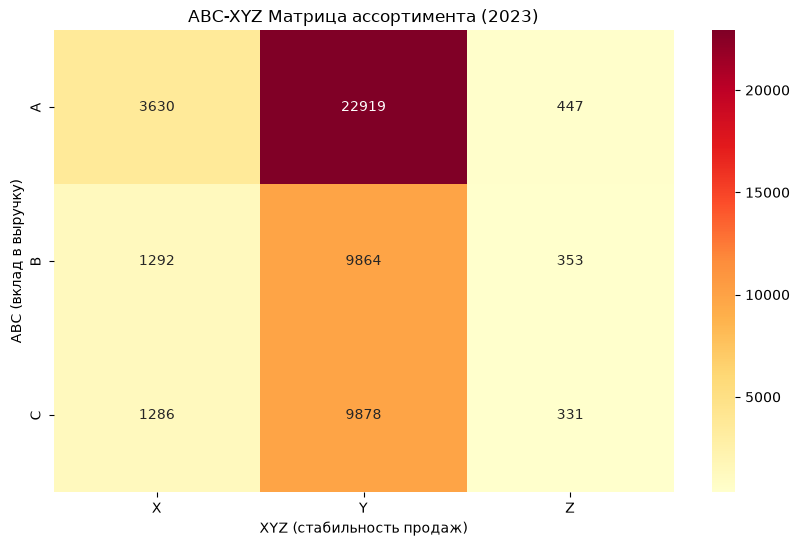

In [15]:
abc_xyz_matrix = pd.crosstab(product_stats['abc_class'], product_stats['xyz_class'])
plt.figure(figsize=(10, 6))
sns.heatmap(abc_xyz_matrix, annot=True, fmt='d', cmap='YlOrRd')
plt.title('ABC-XYZ Матрица ассортимента (2023)')
plt.xlabel('XYZ (стабильность продаж)')
plt.ylabel('ABC (вклад в выручку)')
plt.show()

Блок 5. Топ-10 товаров по выручке и по количеству

In [16]:
top_revenue = product_stats.nlargest(10, 'revenue')[['product_id', 'revenue', 'total_quantity', 'unique_clients', 'abc_class', 'xyz_class']]
top_revenue['revenue_mn'] = top_revenue['revenue'] / 1e6
print("Топ-10 товаров по выручке (млн):")
print(top_revenue[['product_id', 'revenue_mn', 'total_quantity', 'abc_class', 'xyz_class']].to_string(index=False))

top_quantity = product_stats.nlargest(10, 'total_quantity')[['product_id', 'total_quantity', 'revenue', 'unique_clients', 'abc_class', 'xyz_class']]
top_quantity['revenue_mn'] = top_quantity['revenue'] / 1e6
print("\nТоп-10 товаров по количеству продаж:")
print(top_quantity[['product_id', 'total_quantity', 'revenue_mn', 'abc_class', 'xyz_class']].to_string(index=False))

Топ-10 товаров по выручке (млн):
 product_id  revenue_mn  total_quantity abc_class xyz_class
      37181  126.506926            2348         A         Y
      30239  122.577085            2121         A         Y
      22406  122.007891            2119         A         Y
      10292  121.115031            2202         A         Y
      45018  118.322228            2235         A         Y
      24299  117.852522            2074         A         X
      11714  113.646456            1963         A         Y
      40657  113.584037            2108         A         Y
        696  112.019601            2425         A         Y
        182  110.779224            2413         A         Y

Топ-10 товаров по количеству продаж:
 product_id  total_quantity  revenue_mn abc_class xyz_class
      25856            2714   49.376030         A         Y
      46596            2539    2.480628         C         Y
      44229            2533   14.852502         B         X
      16114            2484  

Блок 6. Выявление товаров для вывода и для продвижения

In [17]:
# Товары для вывода: низкая маржа, низкие продажи, класс CZ или C с маржой <5%
remove_candidates = product_stats[
    ((product_stats['abc_class'] == 'C') & (product_stats['xyz_class'] == 'Z')) |
    ((product_stats['margin_percent'] < 5) & (product_stats['total_quantity'] < product_stats['total_quantity'].quantile(0.3)))
].sort_values('margin_percent', ascending=True)

print(f"Кандидаты на вывод из ассортимента: {len(remove_candidates)}")
print("Топ-10 кандидатов (по возрастанию маржи):")
print(remove_candidates[['product_id', 'revenue', 'total_quantity', 'margin_percent', 'abc_class', 'xyz_class']].head(10).to_string(index=False))

# Товары для акций/продвижения: средние показатели, но с потенциалом роста (класс B или C с высоким количеством)
growth_candidates = product_stats[
    (product_stats['abc_class'].isin(['B', 'C'])) &
    (product_stats['total_quantity'] > product_stats['total_quantity'].quantile(0.5)) &
    (product_stats['revenue'] > product_stats['revenue'].quantile(0.3))
].sort_values('total_quantity', ascending=False)

print(f"\nКандидаты для стимулирования продаж: {len(growth_candidates)}")
print("Топ-10 кандидатов (по количеству продаж):")
print(growth_candidates[['product_id', 'total_quantity', 'revenue', 'margin_percent', 'abc_class', 'xyz_class']].head(10).to_string(index=False))

Кандидаты на вывод из ассортимента: 331
Топ-10 кандидатов (по возрастанию маржи):
 product_id    revenue  total_quantity  margin_percent abc_class xyz_class
       4256  8132356.0             785       44.816016         C         Z
      49408  9730652.0            1336       45.885024         C         Z
      30834 11768662.0            1149       46.491463         C         Z
      38913  4512051.0            1153       47.016417         C         Z
      41968  9738444.0             894       47.429963         C         Z
      17568  6981253.0             898       47.526288         C         Z
      31408  3312084.0            1038       48.598604         C         Z
      45209 10507775.0             745       48.614631         C         Z
      26367  3828881.0             820       48.687541         C         Z
      36599 14115640.0            1146       48.855625         C         Z

Кандидаты для стимулирования продаж: 3323
Топ-10 кандидатов (по количеству продаж):
 product

Интерпретация результатов

ABC: 26996 товаров класса A (дают 80% выручки), 11509 класса B (15% выручки), 11495 класса C (5% выручки).
Это типичное распределение, близкое к правилу Парето (20/80). Однако у нас A-товаров почти половина ассортимента, что означает, что ассортимент сильно раздут – много товаров приносят мало выручки.

XYZ: X – 6208 (стабильные), Y – 42661 (средняя стабильность), Z – 1131 (нестабильные).
Почти все товары (89%) имеют среднюю стабильность (Y). Это говорит о том, что большинство товаров подвержены сезонным или случайным колебаниям, что нормально. Но Z-товаров мало – всего 2,4%, их можно выделить как кандидатов на вывод.

1. Товары для вывода из ассортимента

У нас есть 331 товар класса CZ (кандидаты на вывод). Это всего 0,7% от общего числа товаров, но они потребляют складские и логистические ресурсы.
Рекомендация: вывести их из ассортимента и заменить на товары, которые имеют более стабильный спрос и лучшую маржинальность.
Дополнительно можно пересмотреть все товары класса C – их 11495. Возможно, часть из них тоже можно объединить или заменить.

2. Товары для акций (стимулирование продаж)

У нас 3323 товара класса B и C с высокими продажами и маржой >55%. Это отличные кандидаты для продвижения.
Рекомендации:

Провести акции со скидкой 10–15% на эти товары, особенно в пиковые дни (среда, суббота) и часы (10–14, 17–20).

Создать тематические наборы (например, «Сделай заказ на 5000 и получи скидку на товар Х»).

Улучшить их видимость на сайте – разместить на главной странице, в рекомендациях, в email-рассылках.

3. Повышение маржинальности

Товары класса A имеют высокую выручку, но не все – высокую маржу.
Рекомендация: для товаров класса A с маржой ниже 20% провести пересмотр цен (повысить на 5–10%) или пересмотреть договоры с поставщиками. Для товаров класса A с высокой маржой – оставить как есть, но поддерживать их стабильные продажи.

Блок 7. RFM-анализ и сегментация клиентов

In [18]:
# RFM-анализ
current_date = df['date'].max()

rfm = df.groupby('client_id').agg({
    'date': lambda x: (current_date - x.max()).days,
    'total_price': ['sum', 'count']
}).reset_index()
rfm.columns = ['client_id', 'recency', 'monetary', 'frequency']

# RFM-баллы
rfm['recency_score'] = pd.qcut(rfm['recency'], 5, labels=[5,4,3,2,1])
rfm['frequency_score'] = pd.qcut(rfm['frequency'].rank(method='first'), 5, labels=[1,2,3,4,5])
rfm['monetary_score'] = pd.qcut(rfm['monetary'], 5, labels=[1,2,3,4,5])

def rfm_segment(row):
    if row['recency_score'] >= 4 and row['frequency_score'] >= 4:
        return 'VIP'
    elif row['recency_score'] >= 4 and row['frequency_score'] >= 2:
        return 'Лояльные'
    elif row['recency_score'] <= 2 and row['frequency_score'] >= 3:
        return 'Потерянные'
    elif row['recency_score'] >= 3:
        return 'Новые'
    else:
        return 'Нерегулярные'

rfm['segment'] = rfm.apply(rfm_segment, axis=1)

print("Распределение клиентов по сегментам:")
print(rfm['segment'].value_counts())

# Статистика по сегментам
print("\nСредние показатели по сегментам:")
print(rfm.groupby('segment').agg({
    'client_id': 'count',
    'monetary': 'mean',
    'frequency': 'mean',
    'recency': 'mean'
}).round(2))

Распределение клиентов по сегментам:
segment
Новые           210472
Нерегулярные    202494
VIP             196400
Потерянные      144959
Лояльные        115641
Name: count, dtype: int64

Средние показатели по сегментам:
              client_id    monetary  frequency  recency
segment                                                
VIP              196400  3102263.43       3.78    33.96
Лояльные         115641  1503296.11       1.84    36.98
Нерегулярные     202494   953681.22       1.17   240.65
Новые            210472  1810789.58       2.21    92.93
Потерянные       144959  2189220.89       2.66   197.89


Блок 8 Анализ по дням недели и часам

Статистика по дням недели:
day_name  transactions      revenue  unique_clients     avg_check
      Пн        286022 2.342003e+11          248973 818819.284303
      Вт        285169 2.341531e+11          248292 821103.070200
      Ср        292260 2.409542e+11          253218 824451.538479
      Чт        292856 2.400741e+11          253890 819768.371063
      Пт        300018 2.466603e+11          259446 822151.657814
      Сб        289504 2.374608e+11          251224 820233.275133
      Вс        294247 2.412068e+11          254864 819742.699807

Средние значения за день: транзакций: 291439, выручка: 239244.24 млн


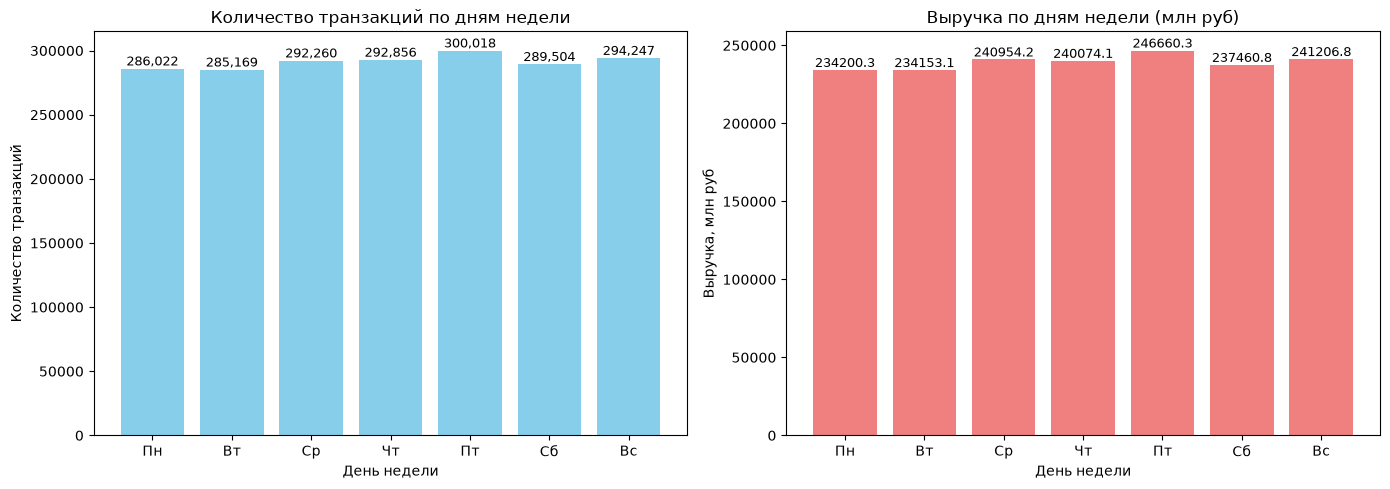

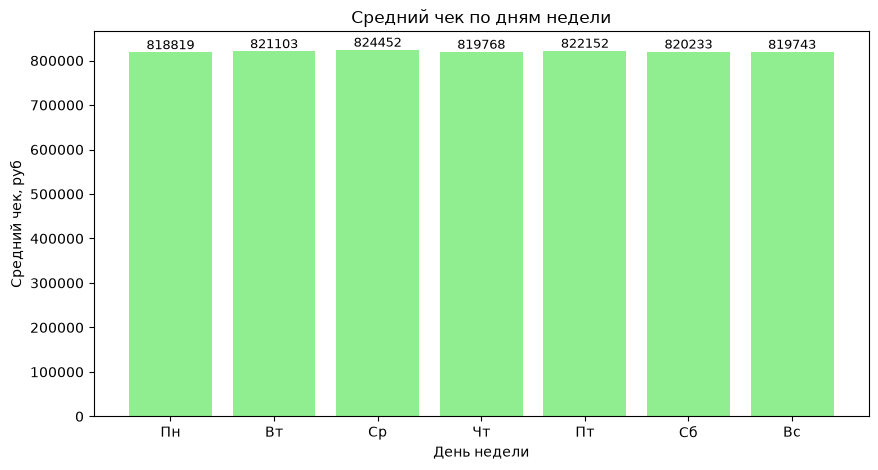

In [22]:
# Анализ по дням недели
day_activity = df.groupby('day_of_week').agg({
    'client_id': 'nunique',
    'total_price': ['sum', 'count', 'mean']
}).reset_index()
day_activity.columns = ['day_of_week', 'unique_clients', 'revenue', 'transactions', 'avg_check']

# Добавляем названия дней
day_names = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']
day_activity['day_name'] = day_activity['day_of_week'].map(dict(zip(range(7), day_names)))

# Сортируем по дню недели
day_activity = day_activity.sort_values('day_of_week')

print("Статистика по дням недели:")
print(day_activity[['day_name', 'transactions', 'revenue', 'unique_clients', 'avg_check']].to_string(index=False))
print(f"\nСредние значения за день: транзакций: {day_activity['transactions'].mean():.0f}, выручка: {day_activity['revenue'].mean()/1e6:.2f} млн")

# Графики
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Количество транзакций
axes[0].bar(day_activity['day_name'], day_activity['transactions'], color='skyblue')
axes[0].set_title('Количество транзакций по дням недели')
axes[0].set_xlabel('День недели')
axes[0].set_ylabel('Количество транзакций')
for i, v in enumerate(day_activity['transactions']):
    axes[0].text(i, v + 50, f'{v:,}', ha='center', va='bottom', fontsize=9)

# Выручка (млн руб)
axes[1].bar(day_activity['day_name'], day_activity['revenue'] / 1e6, color='lightcoral')
axes[1].set_title('Выручка по дням недели (млн руб)')
axes[1].set_xlabel('День недели')
axes[1].set_ylabel('Выручка, млн руб')
for i, v in enumerate(day_activity['revenue'] / 1e6):
    axes[1].text(i, v + 0.5, f'{v:.1f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Средний чек по дням
plt.figure(figsize=(10, 5))
plt.bar(day_activity['day_name'], day_activity['avg_check'], color='lightgreen')
plt.title('Средний чек по дням недели')
plt.xlabel('День недели')
plt.ylabel('Средний чек, руб')
for i, v in enumerate(day_activity['avg_check']):
    plt.text(i, v + 50, f'{v:.0f}', ha='center', va='bottom', fontsize=9)
plt.show()

Интерпретация

1. Анализ по дням недели
Пиковые дни: среда, пятница, воскресенье – в эти дни количество транзакций и выручка максимальны (около 290–300 тыс. транзакций в день).

Рекомендация: проводить ограниченные по времени акции именно в эти дни (например, «скидка 10% на всё» или «двойные бонусы»). Это увеличит конверсию, так как аудитория уже активна.

Низкие дни: понедельник и вторник – активность ниже на 3–5%.

Рекомендация: запускать спецпредложения для привлечения клиентов в эти дни (например, «скидка 15% на второй товар» или «бесплатная доставка при заказе от 5000 руб.»).

2. Сегментация клиентов (RFM)
Распределение по сегментам говорит о сильной и лояльной базе, но есть и потерянные клиенты, которых можно вернуть.

VIP (196 тыс. клиентов) – средний чек 3,1 млн руб., частота покупок 3,78. Это ваши самые ценные клиенты.

Действия: персональные менеджеры, эксклюзивные предложения, ранний доступ к новинкам, повышенный кэшбэк.

Лояльные (115 тыс.) – средний чек 1,5 млн руб., частота 1,84.

Действия: программа лояльности с накопительными бонусами, персональные скидки на товары, которые они уже покупали.

Потерянные (145 тыс.) – не покупали в среднем 198 дней, но их средний чек высокий (2,2 млн руб.).

Действия: reactivation-кампании – отправлять email/SMS со скидкой 20–30% на возврат, предлагать товары, которые они покупали ранее.

Новые (210 тыс.) – средний чек 1,8 млн руб., частота 2,21.

Действия: welcome-предложения (скидка на первый заказ, подарок при регистрации), рекомендации популярных товаров, чтобы повысить частоту покупок.

Нерегулярные (202 тыс.) – низкая частота, давно не покупали.

Действия: стимулировать через email-рассылки с персональными предложениями на основе их истории покупок, предлагать товары, которые они просматривали.